# 2. Machine Learning for Regression

In [1]:
import pandas as pd
import numpy as np

## 2.2 Data Preparation

In [2]:
df = pd.read_csv('../data/data.csv')
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [3]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='str')

In [4]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='str')

In [5]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [6]:
df.dtypes == 'str'

make                  True
model                 True
year                 False
engine_fuel_type      True
engine_hp            False
engine_cylinders     False
transmission_type     True
driven_wheels         True
number_of_doors      False
market_category       True
vehicle_size          True
vehicle_style         True
highway_mpg          False
city_mpg             False
popularity           False
msrp                 False
dtype: bool

In [7]:
df.dtypes[df.dtypes == 'str']

make                 str
model                str
engine_fuel_type     str
transmission_type    str
driven_wheels        str
market_category      str
vehicle_size         str
vehicle_style        str
dtype: object

In [8]:
strings = list(df.dtypes[df.dtypes == 'str'].index)
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [9]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [10]:
df[strings]

,make,model,engine_fuel_type,transmission_type,driven_wheels,market_category,vehicle_size,vehicle_style
0,bmw,1_series_m,premium_unleaded_(required),manual,rear_wheel_drive,"factory_tuner,luxury,high-performance",compact,coupe
1,bmw,1_series,premium_unleaded_(required),manual,rear_wheel_drive,"luxury,performance",compact,convertible
2,bmw,1_series,premium_unleaded_(required),manual,rear_wheel_drive,"luxury,high-performance",compact,coupe
3,bmw,1_series,premium_unleaded_(required),manual,rear_wheel_drive,"luxury,performance",compact,coupe
4,bmw,1_series,premium_unleaded_(required),manual,rear_wheel_drive,luxury,compact,convertible
...,...,...,...,...,...,...,...,...
11909,acura,zdx,premium_unleaded_(required),automatic,all_wheel_drive,"crossover,hatchback,luxury",midsize,4dr_hatchback
11910,acura,zdx,premium_unleaded_(required),automatic,all_wheel_drive,"crossover,hatchback,luxury",midsize,4dr_hatchback
11911,acura,zdx,premium_unleaded_(required),automatic,all_wheel_drive,"crossover,hatchback,luxury",midsize,4dr_hatchback
11912,acura,zdx,premium_unleaded_(recommended),automatic,all_wheel_drive,"crossover,hatchback,luxury",midsize,4dr_hatchback


In [11]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

## 2.3 Exploratory data analysis

In [12]:
df

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,46120
11910,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,56670
11911,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50620
11912,acura,zdx,2013,premium_unleaded_(recommended),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50920


In [13]:
for col in df.columns:
    print(col)
    print(df[col].head())
    print()

make
0    bmw
1    bmw
2    bmw
3    bmw
4    bmw
Name: make, dtype: str

model
0    1_series_m
1      1_series
2      1_series
3      1_series
4      1_series
Name: model, dtype: str

year
0    2011
1    2011
2    2011
3    2011
4    2011
Name: year, dtype: int64

engine_fuel_type
0    premium_unleaded_(required)
1    premium_unleaded_(required)
2    premium_unleaded_(required)
3    premium_unleaded_(required)
4    premium_unleaded_(required)
Name: engine_fuel_type, dtype: str

engine_hp
0    335.0
1    300.0
2    300.0
3    230.0
4    230.0
Name: engine_hp, dtype: float64

engine_cylinders
0    6.0
1    6.0
2    6.0
3    6.0
4    6.0
Name: engine_cylinders, dtype: float64

transmission_type
0    manual
1    manual
2    manual
3    manual
4    manual
Name: transmission_type, dtype: str

driven_wheels
0    rear_wheel_drive
1    rear_wheel_drive
2    rear_wheel_drive
3    rear_wheel_drive
4    rear_wheel_drive
Name: driven_wheels, dtype: str

number_of_doors
0    2.0
1    2.0
2    2.0
3

In [14]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-pe

### Distribution of price

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

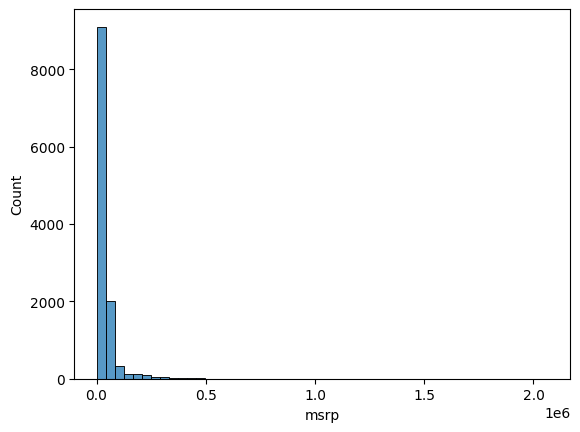

In [16]:
sns.histplot(df.msrp, bins=50);

We can see long tail distribution in the graph above.
1e6 - one million, 1_000_000.
Possible prices might be around 2 million.

Zoom in a bit to see prices up to 100_000

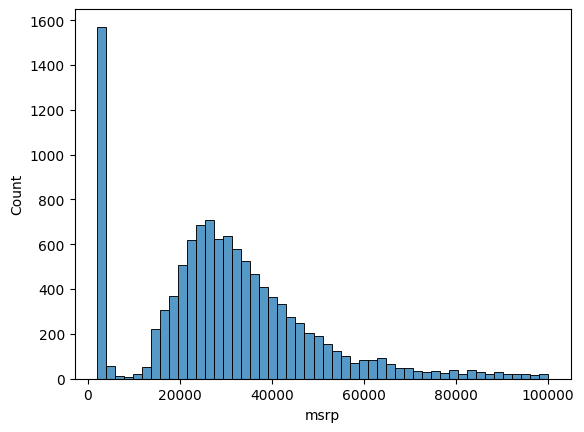

In [17]:
sns.histplot(df.msrp[df.msrp < 100_000], bins=50);

We can see a bunch of cars at minimal price, around 1000, the average in this zoomed in is around 25_000.
This kind of distribution is not very good for ML. The tail from the zoomed-out graph will easily confuse ML models.
We want to get rid of that tail.  
To remove it we apply a logarithms to obtain a logarithnmic distribution to get more compact values.  
What's the reason for that? Simple mathematical behavior of logarithms - log of large values are not increasing rapidly.

In [18]:
np.log([1, 10, 1000, 100_000])

array([ 0.        ,  2.30258509,  6.90775528, 11.51292546])

The problem with common logs is that if we calculate logs for zero values, we will get a warning because the log(0) is undefined.
The solution is add to 1 to all values and then apply a log on them.

In [19]:
np.log([0 + 1, 1 + 1, 10 + 1, 1000 + 1, 100_000 + 1])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

But we don't want to do this manually each time.   
There is a method in numpy that applies such a log on our data.

In [20]:
np.log1p([0, 1, 10, 1000, 100_000])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

In [21]:
price_logs = np.log1p(df.msrp)

In [22]:
price_logs

0        10.739349
1        10.612779
2        10.500977
3        10.290483
4        10.448744
           ...    
11909    10.739024
11910    10.945018
11911    10.832122
11912    10.838031
11913    10.274913
Name: msrp, Length: 11914, dtype: float64

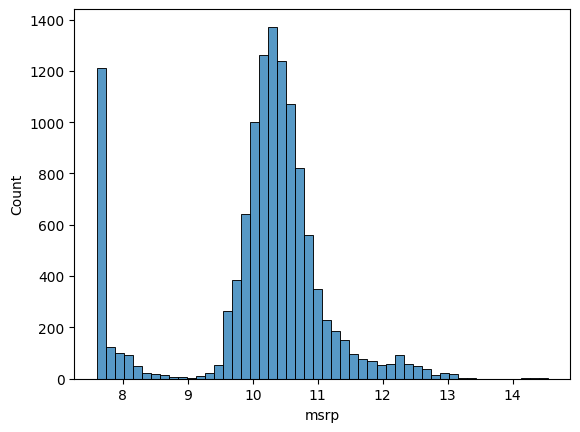

In [23]:
sns.histplot(price_logs, bins=50);

The tail is gone and all large prices have collapsed to the area around 14.
All the prices for usual consumers are pivoting around 10 and 11.
This shape is now called a **normal distribution**.  
Models work best with normal distributions of the target variable.

## Missing values

In [24]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

# 2.4 Setting up the validation framework

In [25]:
len(df)

11914

In [26]:
len(df) * .2

2382.8

In [27]:
n = len(df)
n_val = int(n * .2)
n_test = int(n * .2)
n_train = int(n * .6)

In [28]:
n, n_val + n_test + n_train

(11914, 11912)

We can see that we left out 2 records, so we need different approach.

In [29]:
n_train = n - n_val - n_test
n_train

7150

In [30]:
n, n_val + n_test + n_train

(11914, 11914)

In [31]:
n_val, n_test, n_train

(2382, 2382, 7150)

In [32]:
df_train = df.iloc[:n_train]
df_val = df.iloc[n_train:n_train+n_val]
df_test = df.iloc[n_train+n_val:]

In [33]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,mazda,navajo,1994,regular_unleaded,160.0,6.0,manual,four_wheel_drive,2.0,NaN,compact,2dr_suv,18,14,586,2000
7146,mazda,navajo,1994,regular_unleaded,160.0,6.0,manual,four_wheel_drive,2.0,NaN,compact,2dr_suv,18,14,586,2000
7147,lincoln,navigator,2015,regular_unleaded,365.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,20,15,61,65055
7148,lincoln,navigator,2015,regular_unleaded,365.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,19,15,61,67220


In [34]:
df_val

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
7150,lincoln,navigator,2015,regular_unleaded,365.0,6.0,automatic,rear_wheel_drive,4.0,luxury,large,4dr_suv,20,15,61,63645
7151,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,rear_wheel_drive,4.0,luxury,large,4dr_suv,22,16,61,63195
7152,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,19,15,61,76650
7153,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,19,15,61,69135
7154,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,rear_wheel_drive,4.0,luxury,large,4dr_suv,20,15,61,65560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9527,chevrolet,silverado_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,22,17,1385,37380
9528,chevrolet,silverado_1500,2015,regular_unleaded,355.0,8.0,automatic,rear_wheel_drive,4.0,NaN,large,extended_cab_pickup,23,16,1385,40100
9529,chevrolet,silverado_1500,2015,regular_unleaded,355.0,8.0,automatic,rear_wheel_drive,4.0,NaN,large,crew_cab_pickup,23,16,1385,42560
9530,chevrolet,silverado_1500,2015,regular_unleaded,355.0,8.0,automatic,rear_wheel_drive,4.0,NaN,large,crew_cab_pickup,23,16,1385,42860


In [35]:
df_test

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
9532,chevrolet,silverado_1500,2015,regular_unleaded,355.0,8.0,automatic,rear_wheel_drive,4.0,NaN,large,crew_cab_pickup,23,16,1385,47575
9533,chevrolet,silverado_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,rear_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,24,18,1385,31940
9534,chevrolet,silverado_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,rear_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,24,18,1385,38335
9535,chevrolet,silverado_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,rear_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,24,18,1385,35870
9536,chevrolet,silverado_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,rear_wheel_drive,2.0,flex_fuel,large,regular_cab_pickup,24,18,1385,28155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,46120
11910,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,56670
11911,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50620
11912,acura,zdx,2013,premium_unleaded_(recommended),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50920


Another problem is that all the data is sequential - we have to shuffle the data.

In [36]:
idx = np.arange(n)

In [37]:
idx

array([    0,     1,     2, ..., 11911, 11912, 11913], shape=(11914,))

In [38]:
np.random.shuffle(idx)

In [39]:
idx

array([  868,  9500,  6870, ...,  5471, 10343,  8812], shape=(11914,))

In [40]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

In [41]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
868,saab,9-5,2011,premium_unleaded_(recommended),220.0,4.0,automatic,front_wheel_drive,4.0,luxury,large,sedan,28,18,376,43435
9500,chevrolet,silverado_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,rear_wheel_drive,2.0,flex_fuel,large,regular_cab_pickup,24,18,1385,33340
6870,lincoln,mks,2016,premium_unleaded_(recommended),365.0,6.0,automatic,all_wheel_drive,4.0,"luxury,performance",large,sedan,24,16,61,46000
727,bmw,7_series,2015,premium_unleaded_(required),445.0,8.0,automatic,all_wheel_drive,4.0,"luxury,high-performance",large,sedan,24,16,3916,90300
9722,hyundai,sonata,2015,regular_unleaded,185.0,4.0,automatic,front_wheel_drive,4.0,NaN,midsize,sedan,35,24,1439,26525
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4329,ford,expedition,2016,regular_unleaded,365.0,6.0,automatic,rear_wheel_drive,4.0,NaN,large,4dr_suv,21,15,5657,44410
6572,mercedes-benz,m-class,2014,diesel,240.0,6.0,automatic,all_wheel_drive,4.0,"crossover,luxury,diesel",midsize,4dr_suv,28,20,617,51790
2217,toyota,camry_solara,2006,regular_unleaded,225.0,6.0,automatic,front_wheel_drive,2.0,NaN,midsize,coupe,27,18,2031,21860
9311,gmc,sierra_1500_hybrid,2013,regular_unleaded,332.0,8.0,automatic,rear_wheel_drive,4.0,hybrid,large,crew_cab_pickup,23,20,549,48335


The problem with this approach that each time we will get different random portions.  
We need to keep it reproducible with pseudo-random shuffling. 

In [42]:
np.random.seed(2)
np.random.shuffle(idx)

Split the data again.

In [43]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

In [44]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
1296,bmw,activehybrid_7,2014,premium_unleaded_(required),350.0,6.0,automatic,rear_wheel_drive,4.0,"luxury,performance,hybrid",large,sedan,30,22,3916,84300
5580,lexus,gs_350,2017,premium_unleaded_(required),311.0,6.0,automatic,all_wheel_drive,4.0,"luxury,performance",midsize,sedan,26,19,454,56555
4922,ford,freestar,2006,regular_unleaded,193.0,6.0,automatic,front_wheel_drive,4.0,NaN,midsize,passenger_minivan,22,16,5657,23655
4920,ford,freestar,2006,regular_unleaded,193.0,6.0,automatic,front_wheel_drive,4.0,NaN,midsize,cargo_minivan,22,16,5657,19650
1971,chevrolet,blazer,2003,regular_unleaded,190.0,6.0,automatic,rear_wheel_drive,4.0,NaN,midsize,4dr_suv,21,15,1385,24695
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,mazda,2,2012,regular_unleaded,100.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,34,28,586,15370
2195,chevrolet,camaro,2017,premium_unleaded_(recommended),455.0,8.0,manual,rear_wheel_drive,2.0,high-performance,midsize,coupe,25,16,1385,41905
4259,lotus,evora,2011,premium_unleaded_(required),276.0,6.0,manual,rear_wheel_drive,2.0,"exotic,high-performance",compact,coupe,27,18,613,64000
8412,lexus,rc_350,2016,premium_unleaded_(required),306.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,coupe,28,19,454,42780


In [45]:
df_test

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
1525,cadillac,ats-v,2017,premium_unleaded_(recommended),464.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,23,16,1624,62895
7172,dodge,neon,2004,premium_unleaded_(required),150.0,4.0,manual,front_wheel_drive,4.0,NaN,compact,sedan,32,25,1851,17640
5644,volkswagen,gti,2013,premium_unleaded_(recommended),200.0,4.0,manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,31,21,873,24200
11799,subaru,xv_crosstrek,2014,regular_unleaded,160.0,4.0,automatic,all_wheel_drive,4.0,"crossover,hybrid",compact,4dr_suv,33,29,640,29295
5892,subaru,impreza,2017,regular_unleaded,152.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,mitsubishi,3000gt,1999,regular_unleaded,161.0,6.0,manual,front_wheel_drive,2.0,hatchback,compact,2dr_hatchback,22,17,436,4090
6468,land_rover,lr4,2015,premium_unleaded_(required),340.0,6.0,automatic,four_wheel_drive,4.0,luxury,midsize,4dr_suv,19,14,258,50400
7015,toyota,mr2,1993,regular_unleaded,200.0,4.0,manual,rear_wheel_drive,2.0,performance,compact,coupe,25,18,2031,2078
1267,honda,accord,2017,regular_unleaded,185.0,4.0,automatic,front_wheel_drive,4.0,NaN,midsize,sedan,36,27,2202,27530


In [46]:
df_val

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
4014,gmc,envoy,2008,regular_unleaded,300.0,8.0,automatic,four_wheel_drive,4.0,NaN,midsize,4dr_suv,19,13,549,37105
784,volvo,850,1996,regular_unleaded,240.0,5.0,automatic,front_wheel_drive,4.0,"factory_tuner,luxury,performance",midsize,sedan,24,17,870,2000
4863,kia,forte,2015,regular_unleaded,145.0,4.0,automatic,front_wheel_drive,4.0,NaN,compact,sedan,39,26,1720,17490
10859,nissan,truck,1996,regular_unleaded,134.0,4.0,manual,four_wheel_drive,2.0,NaN,compact,extended_cab_pickup,18,15,2009,2647
9235,toyota,sienna,2016,regular_unleaded,266.0,6.0,automatic,front_wheel_drive,4.0,NaN,large,passenger_minivan,25,18,2031,26745
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2428,toyota,celica,2003,premium_unleaded_(required),180.0,4.0,manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,29,20,2031,22005
7503,honda,passport,2001,regular_unleaded,205.0,6.0,automatic,rear_wheel_drive,4.0,NaN,midsize,4dr_suv,20,15,2202,26800
11750,nissan,xterra,2013,regular_unleaded,261.0,6.0,automatic,rear_wheel_drive,4.0,NaN,midsize,4dr_suv,22,16,2009,22940
5308,mercedes-benz,glc-class,2017,premium_unleaded_(recommended),241.0,4.0,automatic,rear_wheel_drive,4.0,"crossover,luxury",midsize,4dr_suv,28,22,617,39150


In [47]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

We are not interested in the original indices, so we will reset all of them.

In [48]:
df_train = df_train.reset_index(drop=True)

In [49]:
df_val = df_val.reset_index(drop=True)

In [50]:
df_test = df_test.reset_index(drop=True)

Next, we need to do some transformation of the target variable.

In [51]:
df_train.msrp

0       84300
1       56555
2       23655
3       19650
4       24695
        ...  
7145    15370
7146    41905
7147    64000
7148    42780
7149    11685
Name: msrp, Length: 7150, dtype: int64

In [52]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

Remove the target variable from the training, validation and test subsets

In [53]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

In [54]:
len(y_train)

7150

# Linear regression